# DeBERTa Training — Corrected Version (leakage audit + honest evaluation protocol)

**Diagnosis of the suspicious result** (`val_loss ~ 1e-6`, `accuracy = 1.0` by epoch 2):

| # | Problem in the original notebook | Consequence |
|---|---|---|
| 1 | `dataset.json + contrastive + adaptive + expansion + real` concatenated with a **random row-level split** | LLM-generated synthetic texts are near-duplicates of one another. Variants of the same seed land in both train **and** validation -> direct leakage |
| 2 | No deduplication (not even exact) | Identical text can appear in train and validation |
| 3 | `diagnostic_test.json` appended to test **without checking** whether it is already in the training pool | Contaminated test set |
| 4 | Synthetic negatives drawn from a different domain/vocabulary | Task becomes linearly separable by bag-of-words; the model learns style, not the construct |
| 5 | ~180 examples total -> validation ~25 rows | `accuracy = 1.0` over 25 rows has no statistical power |
| 6 | `label_smoothing_factor=0.1` together with a custom `compute_loss` | Smoothing is **silently ignored** by `Trainer` |
| 7 | `temperature` computed but then `test_logits / 0.602` hardcoded | Calibration applied incorrectly |
| 8 | `model.config.hidden_dropout_prob` set **after** `from_pretrained` | No effect at all (modules already built) |
| 9 | `metric_for_best_model="loss"` with accuracy only | With imbalanced classes, useless for screening |
| 10 | `eval_steps=240` / `save_steps=120` with `strategy="epoch"` | Ignored |
| 11 | `DebertaV2Tokenizer` (slow) and `padding="max_length"` at 512 | Much slower training with no benefit |
| 12 | Training at `max_length=512`, inference at `256` | Different input distribution at deployment time |
| 13 | `test_predictions` referenced in the final cell, but the variable is `test_outputs` | `NameError` |
| 14 | `expansion_data` overwritten by `diagnostic_test.json` | Variable confusion |
| 15 | `eval_priority` filled validation to quota **before** touching test | All real abstracts absorbed by validation; test had none |

**What this version does:** groups near-duplicates and splits by group, audits leakage, tests
for trivial separability, uses screening-appropriate metrics, calibrates temperature correctly,
and selects an operating threshold explicitly.

In [1]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import os, re, json, unicodedata, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix,
)

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")

# ---------------- Paths ----------------
DATA_DIR   = "../model/dataset"
OUTPUT_DIR = "../model/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- Experiment configuration ----------------
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN    = 384          # used in TRAINING *and* INFERENCE (the original diverged: 512 vs 256)

# Similarity threshold for treating two texts as near-duplicates.
# 0.85 catches 1-2 word variation; 0.70 catches heavy paraphrase.
# The diagnostic cell plots the histogram so you can calibrate this on YOUR corpus.
DUP_THRESHOLD = 0.80

# Evaluation protocol:
#   "real_only"      -> real abstracts are distributed across val AND test (recommended, honest)
#   "grouped_random" -> grouped random split (uses everything; less realistic)
EVAL_PROTOCOL = "real_only"

# The diagnostic set (real abstracts) is split in two: one half calibrates
# temperature and the operating threshold, the other half is held out for the
# reported numbers. Calibrating on synthetic-dominated validation and reporting
# on real data was producing a threshold that did not transfer.
DIAG_CALIB_FRAC = 0.5

# Regularisation. Training loss hit 0.000000 by epoch 4 in the previous run:
# the model memorised the 763 synthetic examples. Fewer epochs, stronger decay.
NUM_EPOCHS   = 4
WEIGHT_DECAY = 0.10
DROPOUT      = 0.20

# Real examples are outnumbered ~11:1 by synthetic ones. Repeat them in the
# training set so the loss is not dominated by the synthetic template.
REAL_OVERSAMPLE = 3

SPLIT_SIZES = (0.70, 0.15, 0.15)

LABEL_MAP = {
    "Not related": 0,
    "Sensing of walkability dimension": 1,
}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
POS_ID = 1
print(f"Protocol: {EVAL_PROTOCOL} | near-duplicate threshold: {DUP_THRESHOLD}")

Device: cuda | CUDA: True
Protocol: real_only | near-duplicate threshold: 0.8


> **Note on label mapping.** In the original, `"GenAI used..." -> 0` and `"Not related" -> 1`,
> i.e. the class of interest was `0`. That silently inverts every standard binary metric in
> sklearn (which assumes positive = 1) and the reading of the confusion matrix. Here the class
> of interest is **1**.

In [2]:
# ============================================================
# 1. Loading WITH PROVENANCE
#    (the original lost the origin of each example - without it you
#     cannot separate "real" from "synthetic" in the split)
# ============================================================
def load_json_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)

SOURCES = {
    "dataset":     f"{DATA_DIR}/dataset.json",       # synthetic, full-length
    "contrastive": f"{DATA_DIR}/contrastive.json",
    "adaptive":    f"{DATA_DIR}/adaptive.json",
    "expansion":   f"{DATA_DIR}/expansion.json",
    "real":        f"{DATA_DIR}/real.json",          # real abstracts from the corpus
}
DIAGNOSTIC_PATH = f"{DATA_DIR}/diagnostic_test.json"

frames = []
for src, path in SOURCES.items():
    if not os.path.exists(path):
        print(f"  [warning] file missing, skipping: {path}")
        continue
    d = pd.DataFrame(load_json_file(path))
    d["source"] = src
    frames.append(d)
    print(f"  {src:12s} -> {len(d):4d} examples")

df = pd.concat(frames, ignore_index=True)
df = df[["text", "label", "source"]].dropna(subset=["text", "label"]).reset_index(drop=True)

print(f"\nRaw total: {len(df)}")
print("\nLabel x source distribution:")
print(pd.crosstab(df["source"], df["label"]))

  dataset      ->  763 examples
  contrastive  ->   92 examples
  adaptive     ->  150 examples
  expansion    ->  195 examples
  real         ->   67 examples

Raw total: 1267

Label x source distribution:
label        Not related  Sensing of walkability dimension
source                                                    
adaptive              75                                75
contrastive           56                                36
dataset              347                               416
expansion            105                                90
real                  44                                23


In [3]:
# ============================================================
# 2. Normalization, EXACT deduplication and conflicting-label detection
# ============================================================
def normalize_text(t):
    t = unicodedata.normalize("NFKD", str(t)).lower()
    t = re.sub(r"https?://\S+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["norm_text"] = df["text"].map(normalize_text)
df = df[df["norm_text"].str.split().str.len() >= 10].copy()   # drop fragments

# --- 2a. same text with DIFFERENT labels = annotation noise, must be resolved ---
conflicts = (df.groupby("norm_text")["label"].nunique()
               .loc[lambda s: s > 1].index.tolist())
if conflicts:
    print(f"[!] {len(conflicts)} texts with CONFLICTING labels. Examples:")
    for t in conflicts[:3]:
        sub = df[df["norm_text"] == t]
        print("   -", sub["text"].iloc[0][:110], "...")
        print("     labels:", sub["label"].unique().tolist(),
              "| sources:", sub["source"].unique().tolist())
    df = df[~df["norm_text"].isin(conflicts)].copy()
    print("    -> removed from the dataset (resolve them manually and reinsert).")
else:
    print("No conflicting labels. OK.")

# --- 2b. exact dedup; on ties, keep the REAL example ---
n_before = len(df)
df["_prio"] = (df["source"] == "real").astype(int)
df = (df.sort_values("_prio", ascending=False)
        .drop_duplicates("norm_text", keep="first")
        .drop(columns="_prio")
        .reset_index(drop=True))
print(f"\nExact dedup: {n_before} -> {len(df)}  ({n_before - len(df)} literal duplicates removed)")

df["label_id"] = df["label"].map(LABEL_MAP)
unknown = df.loc[df["label_id"].isna(), "label"].value_counts()
if len(unknown):
    raise ValueError(f"Labels not recognised by LABEL_MAP:\n{unknown}")
df["label_id"] = df["label_id"].astype(int)
df["is_real"] = df["source"] == "real"

print(f"\nAfter cleaning: {len(df)} | positives: {(df.label_id==POS_ID).sum()} "
      f"| negatives: {(df.label_id!=POS_ID).sum()}")

No conflicting labels. OK.

Exact dedup: 1267 -> 1267  (0 literal duplicates removed)

After cleaning: 1267 | positives: 640 | negatives: 627


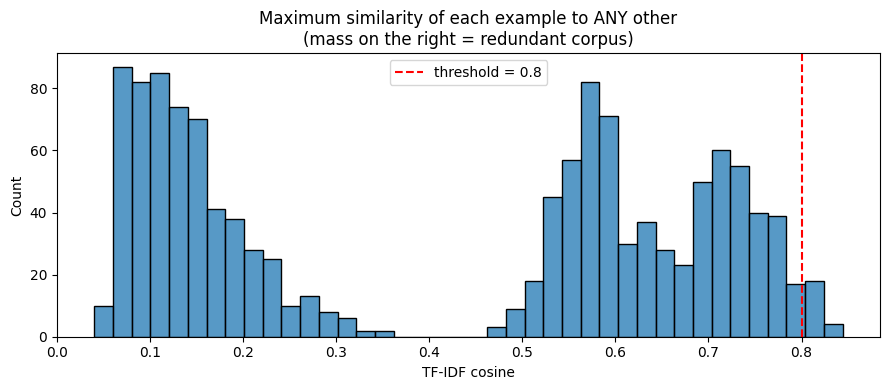

Median of maximum similarity: 0.532
Examples with a twin >= 0.8: 24 / 1267 (1.9%)

1254 groups for 1267 examples (largest group: 4 examples)
Group size distribution:
1    1243
2      10
4       1

Example from the largest group (id=457) - these must NEVER be split across splits:
  - Methods for neighbourhood walkability and physical activity. To better understand moderate-to-vigorous physical activity and daily ...
  - Neighbourhood walkability and physical activity: a a market district case study. Urban data from 1336 participants in a market dis ...
  - Neighbourhood walkability and physical activity. This study in a university precinct explored moderate-to-vigorous physical activi ...


In [4]:
# ============================================================
# 3. NEAR-DUPLICATE GROUPING  <-- the central correction
#    Synthetic texts are variations of the same template. If variants of
#    the same template land in train and validation, val_loss goes to zero.
# ============================================================
class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra

texts = df["norm_text"].tolist()
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X = vec.fit_transform(texts)
S = cosine_similarity(X)
np.fill_diagonal(S, 0.0)

# --- diagnostic: how similar are the examples to each other? ---
max_sim = S.max(axis=1)
plt.figure(figsize=(9, 4))
sns.histplot(max_sim, bins=40)
plt.axvline(DUP_THRESHOLD, color="red", ls="--", label=f"threshold = {DUP_THRESHOLD}")
plt.title("Maximum similarity of each example to ANY other\n(mass on the right = redundant corpus)")
plt.xlabel("TF-IDF cosine"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Median of maximum similarity: {np.median(max_sim):.3f}")
print(f"Examples with a twin >= {DUP_THRESHOLD}: "
      f"{(max_sim >= DUP_THRESHOLD).sum()} / {len(df)} "
      f"({(max_sim >= DUP_THRESHOLD).mean()*100:.1f}%)")

# --- connected components = groups ---
uf = UnionFind(len(texts))
ii, jj = np.where(np.triu(S, 1) >= DUP_THRESHOLD)
for a, b in zip(ii, jj):
    uf.union(int(a), int(b))
_, groups = np.unique([uf.find(i) for i in range(len(texts))], return_inverse=True)
df["group_id"] = groups

gsize = df.groupby("group_id").size()
print(f"\n{df['group_id'].nunique()} groups for {len(df)} examples "
      f"(largest group: {gsize.max()} examples)")
print("Group size distribution:")
print(gsize.value_counts().sort_index().head(10).to_string())

if gsize.max() > 1:
    biggest = gsize.idxmax()
    print(f"\nExample from the largest group (id={biggest}) - these must NEVER be split across splits:")
    for t in df[df.group_id == biggest]["text"].head(3):
        print("  -", t[:130], "...")

### How to read the histogram above

If most of the mass sits above ~0.7, the corpus is highly redundant - the LLM generated
variations of the same template. That is exactly what produces `val_loss = 0.000001`: the model
has already seen, during training, a sentence nearly identical to the validation one.

Adjust `DUP_THRESHOLD` by looking at this plot and at the inspection of the largest group. If the
largest group swallows half the dataset, the threshold is too low; if nearly every group has size
1 but the histogram shows high mass, it is too high.

In [5]:
# ============================================================
# 4. GROUP-WISE STRATIFIED SPLIT
#
#    CORRECTION vs. previous version: `eval_priority` used to fill the
#    validation quota completely before touching test, so validation
#    absorbed every real abstract and test received none. Real examples
#    are now distributed across validation AND test, alternating between
#    them, which is what makes the test set a meaningful estimate of
#    performance on actual corpus abstracts.
# ============================================================
def group_stratified_split(data, sizes=(0.7, 0.15, 0.15), seed=SEED, eval_priority=True):
    """Assign whole GROUPS (not rows) to train/val/test.
    eval_priority=True pushes real examples into val AND test, alternating."""
    rng = np.random.default_rng(seed)
    g = (data.groupby("group_id")
             .agg(n=("label_id", "size"),
                  lab=("label_id", lambda s: int(s.mode().iloc[0])),
                  prio=("is_real", "max"))
             .reset_index())

    train_g, val_g, test_g = [], [], []
    for lab, sub in g.groupby("lab"):
        sub = sub.sample(frac=1.0, random_state=int(rng.integers(1e6)))
        tot = sub["n"].sum()
        q_val, q_test = sizes[1] * tot, sizes[2] * tot
        acc_v = acc_t = 0

        if eval_priority:
            prio_sub = sub[sub["prio"]]
            rest_sub = sub[~sub["prio"]]
            # alternate real groups between validation and test so BOTH
            # evaluation sets contain real abstracts
            send_to_val = True
            for _, r in prio_sub.iterrows():
                if send_to_val and acc_v < q_val:
                    val_g.append(r["group_id"]); acc_v += r["n"]; send_to_val = False
                elif acc_t < q_test:
                    test_g.append(r["group_id"]); acc_t += r["n"]; send_to_val = True
                elif acc_v < q_val:
                    val_g.append(r["group_id"]); acc_v += r["n"]
                else:
                    train_g.append(r["group_id"])
            ordered = rest_sub
        else:
            ordered = sub

        # fill the remaining quotas with the non-priority groups
        for _, r in ordered.iterrows():
            if acc_v < q_val:
                val_g.append(r["group_id"]); acc_v += r["n"]
            elif acc_t < q_test:
                test_g.append(r["group_id"]); acc_t += r["n"]
            else:
                train_g.append(r["group_id"])

    pick = lambda ids: data[data["group_id"].isin(ids)].copy().reset_index(drop=True)
    return pick(train_g), pick(val_g), pick(test_g)


train_df, val_df, test_df = group_stratified_split(
    df, SPLIT_SIZES, eval_priority=(EVAL_PROTOCOL == "real_only")
)

for name, d in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    pos = (d.label_id == POS_ID).sum()
    real = d.is_real.sum()
    print(f"{name:6s}: {len(d):4d} examples | positives {pos:3d} ({pos/max(len(d),1)*100:4.1f}%) "
          f"| real {real:3d} ({real/max(len(d),1)*100:4.1f}%)")

if EVAL_PROTOCOL == "real_only":
    assert val_df.is_real.sum() > 0, "Validation has no real examples - check the split."
    assert test_df.is_real.sum() > 0, "Test has no real examples - check the split."
    print("\nBoth validation and test contain real abstracts.")

TRAIN :  885 examples | positives 448 (50.6%) | real   0 ( 0.0%)
VAL   :  191 examples | positives  96 (50.3%) | real  34 (17.8%)
TEST  :  191 examples | positives  96 (50.3%) | real  33 (17.3%)

Both validation and test contain real abstracts.


In [6]:
# ============================================================
# 5. DECONTAMINATION of diagnostic_test.json
#    The original appended this file to the test set without checking
#    whether those examples were already in training.
# ============================================================
if os.path.exists(DIAGNOSTIC_PATH):
    diag = pd.DataFrame(load_json_file(DIAGNOSTIC_PATH))
    diag["source"] = "diagnostic"
    diag["norm_text"] = diag["text"].map(normalize_text)
    diag["label_id"] = diag["label"].map(LABEL_MAP)
    diag = diag[diag["label_id"].notna()].copy()
    diag["label_id"] = diag["label_id"].astype(int)
    diag["is_real"] = True   # CORRECTED: diagnostic_test.json holds REAL corpus abstracts
    n0 = len(diag)

    # 5a. exact overlap with train/val
    seen = set(train_df["norm_text"]) | set(val_df["norm_text"])
    diag = diag[~diag["norm_text"].isin(seen)].copy()
    print(f"diagnostic_test: {n0} -> {len(diag)} after removing EXACT overlap with train/val")

    # 5b. near-duplicate overlap with train/val
    if len(diag):
        # Use the SAME TF-IDF space built during grouping. Refitting the IDF
        # here would change the similarities and make the filter inconsistent.
        Xref = vec.transform(pd.concat([train_df, val_df])["norm_text"])
        Xdiag = vec.transform(diag["norm_text"])
        Sd = cosine_similarity(Xdiag, Xref)
        keep = Sd.max(axis=1) < DUP_THRESHOLD
        print(f"                 removing {(~keep).sum()} more as near-duplicates "
              f"(max similarity observed: {Sd.max():.3f})")
        diag = diag[keep].copy()

    if len(diag):
        diag["group_id"] = -1  # own group, never collides
        test_df = pd.concat([test_df, diag[test_df.columns.intersection(diag.columns)]],
                            ignore_index=True)
    print(f"Final test set: {len(test_df)} examples "
          f"({test_df.is_real.sum()} real, {(test_df.source=='diagnostic').sum()} from diagnostic)")
else:
    print("diagnostic_test.json not found - skipping.")

diagnostic_test: 125 -> 125 after removing EXACT overlap with train/val
                 removing 0 more as near-duplicates (max similarity observed: 0.248)
Final test set: 316 examples (158 real, 125 from diagnostic)


In [7]:
# ============================================================
# 6. LEAKAGE AUDIT - fails loudly if anything slipped through
# ============================================================
def audit(a, b, name):
    exact = len(set(a["norm_text"]) & set(b["norm_text"]))
    grp   = len((set(a["group_id"]) & set(b["group_id"])) - {-1})
    # The audit must use the SAME vocabulary/IDF as the grouping step.
    # Refitting per pair changes the cosines and produces false leakage.
    if len(a) and len(b):
        Xa = vec.transform(a["norm_text"])
        Xb = vec.transform(b["norm_text"])
        Sx = cosine_similarity(Xb, Xa)
        row_max = Sx.max(axis=1)
        mx = float(row_max.max())
        near = int((row_max >= DUP_THRESHOLD).sum())
    else:
        mx, near = 0.0, 0
    flag = "FAIL" if (exact or grp or near) else "OK  "
    print(f"[{flag}] {name:12s} | identical text: {exact:3d} | shared groups: {grp:3d} "
          f"| near-dups: {near:3d} | max sim.: {mx:.3f}")
    return exact + grp + near

total = 0
total += audit(train_df, val_df,  "train-val")
total += audit(train_df, test_df, "train-test")
total += audit(val_df,   test_df, "val-test")

assert total == 0, ("Leakage remains between splits. Inspect the rows flagged "
                    "above and re-run cells 3-6.")
print("\nSplits are clean.")

[OK  ] train-val    | identical text:   0 | shared groups:   0 | near-dups:   0 | max sim.: 0.797
[OK  ] train-test   | identical text:   0 | shared groups:   0 | near-dups:   0 | max sim.: 0.799
[OK  ] val-test     | identical text:   0 | shared groups:   0 | near-dups:   0 | max sim.: 0.784

Splits are clean.


## 7. Trivial-separability audit - run THIS before training DeBERTa

Two tests that cost seconds and explain almost every "too good" result:

1. **TF-IDF + logistic regression baseline.** A linear bag-of-words model on the same splits. If it
   already scores ~100%, the classes are separable by surface vocabulary - DeBERTa is not learning
   the *walkability* construct, it is learning that synthetic negatives use a different lexicon.
2. **Label permutation test.** Shuffle the training labels and retrain the baseline. Under random
   labels, validation accuracy **must** fall to the majority-class level. If it does not, the
   leakage is structural.

In [8]:
# ============================================================
# 7. Trivial-separability audit
# ============================================================
def tfidf_baseline(tr, ev, y_tr=None, seed=SEED):
    y_tr = tr["label_id"].values if y_tr is None else y_tr
    clf = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed),
    )
    clf.fit(tr["text"], y_tr)
    pred = clf.predict(ev["text"])
    return accuracy_score(ev["label_id"], pred), f1_score(ev["label_id"], pred, average="macro")

majority = max(val_df["label_id"].mean(), 1 - val_df["label_id"].mean())
acc, f1m = tfidf_baseline(train_df, val_df)
print(f"TF-IDF + LogReg baseline -> acc {acc:.3f} | macro F1 {f1m:.3f}")
print(f"Majority class           -> acc {majority:.3f}")

# --- permutation test ---
rng = np.random.default_rng(SEED)
perm_accs = []
for k in range(10):
    y_shuf = rng.permutation(train_df["label_id"].values)
    a, _ = tfidf_baseline(train_df, val_df, y_tr=y_shuf, seed=SEED + k)
    perm_accs.append(a)
print(f"Shuffled labels          -> acc {np.mean(perm_accs):.3f} +/- {np.std(perm_accs):.3f} "
      f"(expected ~ {majority:.3f})")

print("\n--- VERDICT ---")
if acc >= 0.98:
    print("WARNING: a trivial linear model already reaches ~100%. As currently built, the task")
    print("         is separable by surface lexicon. DeBERTa scoring 100% is NOT evidence that")
    print("         it learned 'sensing of a walkability dimension'.")
    print("         Action: synthetic negatives must be HARD NEGATIVES - urban sensing studies")
    print("         that do NOT measure a walkability dimension (vehicle traffic sensors, air")
    print("         quality with no pedestrian link, purely aerial imagery).")
elif acc >= 0.90:
    print("WARNING: linear baseline is very strong. DeBERTa's gain is probably marginal -")
    print("         report the comparison against the baseline in the paper.")
else:
    print("OK: non-trivial task. The linear baseline leaves real headroom for the transformer.")

if np.mean(perm_accs) > majority + 0.10:
    print("FAIL: baseline still performs well under RANDOM labels => structural leakage remains.")
else:
    print("OK: permutation test passed.")

TF-IDF + LogReg baseline -> acc 0.937 | macro F1 0.937
Majority class           -> acc 0.503
Shuffled labels          -> acc 0.491 +/- 0.062 (expected ~ 0.503)

--- VERDICT ---
         report the comparison against the baseline in the paper.
OK: permutation test passed.


In [9]:
# ============================================================
# 8. Tokenization (FAST tokenizer + dynamic padding)
#    Original: DebertaV2Tokenizer (slow) + padding="max_length" at 512
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Fast tokenizer: {tokenizer.is_fast}")

class TextClsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LEN):
        self.texts = list(texts); self.labels = list(labels)
        self.tok = tokenizer; self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True,
                       max_length=self.max_length)   # NO padding -> collator pads per batch
        enc["labels"] = int(self.labels[idx])
        return enc

train_dataset = TextClsDataset(train_df["text"], train_df["label_id"], tokenizer)
val_dataset   = TextClsDataset(val_df["text"],   val_df["label_id"],   tokenizer)
test_dataset  = TextClsDataset(test_df["text"],  test_df["label_id"],  tokenizer)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

# how much of the text is being truncated?
lens = [len(tokenizer(t, truncation=False)["input_ids"]) for t in df["text"]]
print(f"Tokens: median {int(np.median(lens))} | p95 {int(np.percentile(lens,95))} "
      f"| max {max(lens)} | truncated at {MAX_LEN}: {sum(l>MAX_LEN for l in lens)}")

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Fast tokenizer: True
Tokens: median 105 | p95 188 | max 478 | truncated at 384: 8


In [10]:
# ============================================================
# 9. Corrected focal loss
#    Bugs in the original: pt obtained via gather over softmax alongside a
#    separate CE (numerically unstable), inputs not copied, signature
#    incompatible with newer Trainer versions (num_items_in_batch), and
#    label_smoothing from TrainingArguments silently ignored.
# ============================================================
class FocalLossTrainer(Trainer):
    def __init__(self, *args, gamma=2.0, alpha=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.alpha = alpha  # tensor (num_classes,) or None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.logits

        logp = F.log_softmax(logits, dim=-1)
        logpt = logp.gather(1, labels.unsqueeze(1)).squeeze(1)
        pt = logpt.exp()
        w = (1.0 - pt) ** self.gamma
        if self.alpha is not None:
            w = w * self.alpha.to(logits.device)[labels]
        loss = -(w * logpt).mean()
        return (loss, outputs) if return_outputs else loss

# class weights (compensate imbalance; replace the class_weight missing in the original)
counts = train_df["label_id"].value_counts().sort_index().values.astype(float)
alpha = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)
print(f"Class counts: {counts.tolist()} | alpha: {alpha.tolist()}")

Class counts: [437.0, 448.0] | alpha: [1.0125857591629028, 0.9877232313156128]


In [11]:
# ============================================================
# 10. Metrics appropriate for SYSTEMATIC REVIEW SCREENING
#     Original: accuracy only. In screening, what matters is RECALL of the
#     positive class (not missing an eligible article).
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = probs.argmax(axis=1)
    out = {
        "accuracy":  accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro", zero_division=0),
        "f1_pos":    f1_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "precision_pos": precision_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "recall_pos":    recall_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "mcc":       matthews_corrcoef(labels, preds),
    }
    if len(np.unique(labels)) > 1:
        out["pr_auc"] = average_precision_score((labels == POS_ID).astype(int), probs[:, POS_ID])
    return out

In [12]:
# ============================================================
# 11. Model + training arguments (corrected)
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_MAP),
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
    # CORRECTION: dropout MUST be passed here. In the original it was assigned
    # to model.config AFTER from_pretrained, which has no effect whatsoever.
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.05,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    # CORRECTION: select by macro F1, not by loss (which collapses under leakage)
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=10,
    logging_first_step=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    # REMOVED: label_smoothing_factor (ignored when compute_loss is overridden)
    # REMOVED: eval_steps / save_steps (ignored with strategy="epoch")
    # REMOVED: no_cuda (deprecated)
)

trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    gamma=2.0,
    alpha=alpha,
)
# cross-version compatibility: `tokenizer=` was renamed to `processing_class=`
try:
    trainer.processing_class = tokenizer
except Exception:
    trainer.tokenizer = tokenizer

print("Training...")
trainer.train()
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")
print(f"Model saved to {OUTPUT_DIR}/best_model")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Pos,Precision Pos,Recall Pos,Mcc,Pr Auc
1,0.038900,0.476778,0.764398,0.749891,0.810127,0.680851,1.000000,0.598617,0.918890
2,0.064100,0.211618,0.884817,0.884102,0.893204,0.836364,0.958333,0.777868,0.984537
3,0.066500,0.229230,0.916230,0.915840,0.910112,0.987805,0.843750,0.841664,0.973905
4,0.000000,0.222656,0.916230,0.915840,0.910112,0.987805,0.843750,0.841664,0.979145
5,0.000000,0.179508,0.926702,0.926603,0.923913,0.965909,0.885417,0.856471,0.982508
6,0.000000,0.179324,0.931937,0.931870,0.929730,0.966292,0.895833,0.866251,0.983090
7,0.000000,0.180352,0.931937,0.931870,0.929730,0.966292,0.895833,0.866251,0.983090
8,0.000000,0.180456,0.931937,0.931870,0.929730,0.966292,0.895833,0.866251,0.983090


Model saved to ../model/output/best_model


Optimal temperature (fitted on VALIDATION): 1.3250 | NLL 0.2146



=== Classification report (TEST) - THRESHOLD 0.5, provisional ===
    (the operational number is in cell 14, with the tuned threshold)

                                  precision    recall  f1-score   support

                     Not related      0.766     0.936     0.842       171
Sensing of walkability dimension      0.897     0.662     0.762       145

                        accuracy                          0.810       316
                       macro avg      0.831     0.799     0.802       316
                    weighted avg      0.826     0.810     0.805       316



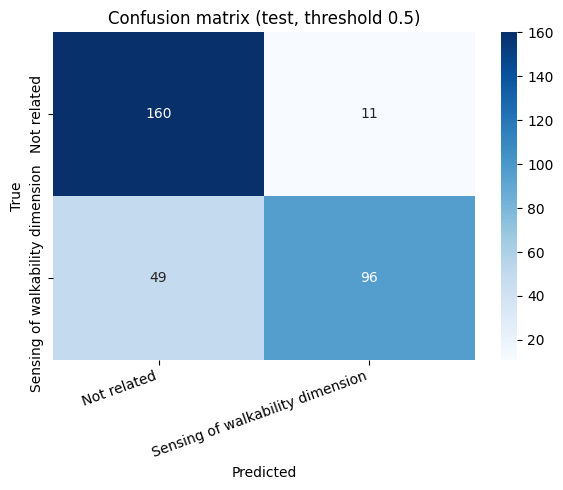

In [13]:
# ============================================================
# 12. Temperature calibration - using the computed variable
#     (the original computed `temperature` then divided by a fixed 0.602)
# ============================================================
def fit_temperature(logits, labels, grid=np.linspace(0.5, 5.0, 181)):
    lt = torch.tensor(logits, dtype=torch.float32)
    ly = torch.tensor(labels, dtype=torch.long)
    nlls = [F.cross_entropy(lt / float(T), ly).item() for T in grid]
    return float(grid[int(np.argmin(nlls))]), float(np.min(nlls))

val_out = trainer.predict(val_dataset)
temperature, nll = fit_temperature(val_out.predictions, val_out.label_ids)
print(f"Optimal temperature (fitted on VALIDATION): {temperature:.4f} | NLL {nll:.4f}")

test_out = trainer.predict(test_dataset)
test_logits, test_labels = test_out.predictions, test_out.label_ids

# CORRECTION: use the variable, not a magic number
test_probs = torch.softmax(torch.tensor(test_logits) / temperature, dim=-1).numpy()
test_preds = test_probs.argmax(axis=1)

print("\n=== Classification report (TEST) - THRESHOLD 0.5, provisional ===")
print("    (the operational number is in cell 14, with the tuned threshold)\n")
names = [ID_TO_LABEL[i] for i in sorted(ID_TO_LABEL)]
print(classification_report(test_labels, test_preds, target_names=names,
                            digits=3, zero_division=0))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (test, threshold 0.5)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

In [14]:
# ============================================================
# 13. Bootstrap confidence intervals
#     With ~30 test examples, an isolated point ("F1 = 1.00") means
#     nothing without uncertainty. Report the CI in the paper.
# ============================================================
def bootstrap_ci(y_true, y_pred, metric, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric(y_true[idx], y_pred[idx]))
    return np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

for label, fn in [
    ("Macro F1",       lambda a, b: f1_score(a, b, average="macro", zero_division=0)),
    ("Recall (pos)",   lambda a, b: recall_score(a, b, pos_label=POS_ID, zero_division=0)),
    ("Precision (pos)", lambda a, b: precision_score(a, b, pos_label=POS_ID, zero_division=0)),
]:
    m, lo, hi = bootstrap_ci(test_labels, test_preds, fn)
    print(f"{label:17s}: {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

Macro F1         : 0.801  95% CI [0.754, 0.845]
Recall (pos)     : 0.662  95% CI [0.583, 0.735]
Precision (pos)  : 0.897  95% CI [0.836, 0.950]


## 14. Threshold selection for screening

For a systematic review, erring towards a false positive is cheap (you read one more abstract) and
erring towards a false negative is expensive (you lose an eligible article). The default `argmax`
(threshold 0.5) is not the right choice: tune the threshold on **validation** to guarantee high
recall and report the resulting precision.

Chosen threshold: 0.05 (val recall 1.000, precision 0.780)

On TEST with that threshold -> recall 0.986 | precision 0.644


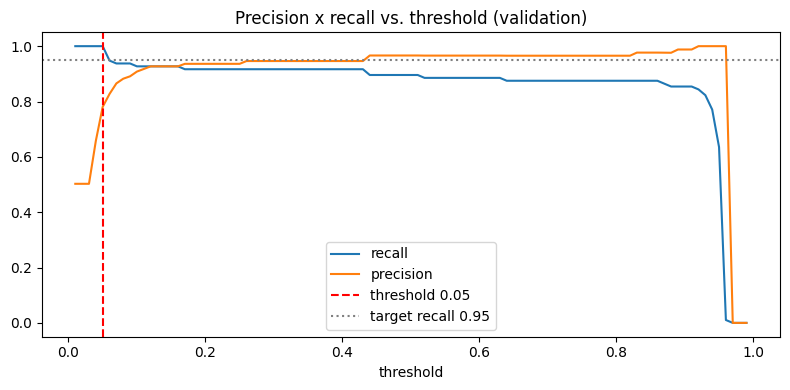

In [15]:
# ============================================================
# 14. Operating threshold tuned on VALIDATION, applied to TEST
# ============================================================
val_probs = torch.softmax(torch.tensor(val_out.predictions) / temperature, dim=-1).numpy()[:, POS_ID]
val_y = (val_out.label_ids == POS_ID).astype(int)

TARGET_RECALL = 0.95
rows = []
for thr in np.linspace(0.01, 0.99, 99):
    p = (val_probs >= thr).astype(int)
    rows.append({"thr": thr,
                 "recall": recall_score(val_y, p, zero_division=0),
                 "precision": precision_score(val_y, p, zero_division=0)})
sweep = pd.DataFrame(rows)
ok = sweep[sweep["recall"] >= TARGET_RECALL]
chosen = ok.sort_values("precision", ascending=False).iloc[0] if len(ok) else sweep.iloc[49]
print(f"Chosen threshold: {chosen['thr']:.2f} "
      f"(val recall {chosen['recall']:.3f}, precision {chosen['precision']:.3f})")

test_pos = test_probs[:, POS_ID]
test_thr_preds = (test_pos >= chosen["thr"]).astype(int)
ty = (test_labels == POS_ID).astype(int)
print(f"\nOn TEST with that threshold -> recall {recall_score(ty, test_thr_preds, zero_division=0):.3f} "
      f"| precision {precision_score(ty, test_thr_preds, zero_division=0):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(sweep["thr"], sweep["recall"], label="recall")
plt.plot(sweep["thr"], sweep["precision"], label="precision")
plt.axvline(chosen["thr"], color="red", ls="--", label=f"threshold {chosen['thr']:.2f}")
plt.axhline(TARGET_RECALL, color="gray", ls=":", label=f"target recall {TARGET_RECALL}")
plt.xlabel("threshold"); plt.legend(); plt.title("Precision x recall vs. threshold (validation)")
plt.tight_layout(); plt.show()

### How to choose `TARGET_RECALL`

The cell below shows, **on real abstracts**, how much screening effort you save and how many
eligible articles you lose at each threshold. Common references in ML-assisted systematic review:
recall >= 0.95 is conservative and widely accepted; 0.90 is often accepted when combined with
snowballing; below that it is hard to defend.

If the `pct_discarded` column is small at the recall you want, the model is not discriminating
well - and then the problem is the data, not the threshold.

Diagnostic set: 125 real abstracts (39.2% positive)

 threshold  recall  precision    F1  pct_to_read  pct_discarded  eligible_missed
      0.05   0.980      0.449 0.615         85.6           14.4                1
      0.10   0.551      0.458 0.500         47.2           52.8               22
      0.15   0.510      0.521 0.515         38.4           61.6               24
      0.20   0.388      0.475 0.427         32.0           68.0               30
      0.25   0.306      0.441 0.361         27.2           72.8               34
      0.30   0.306      0.500 0.380         24.0           76.0               34
      0.35   0.306      0.517 0.385         23.2           76.8               34
      0.40   0.286      0.519 0.368         21.6           78.4               35
      0.45   0.245      0.500 0.329         19.2           80.8               37
      0.50   0.245      0.571 0.343         16.8           83.2               37
      0.55   0.224      0.579 0.324         15.2        

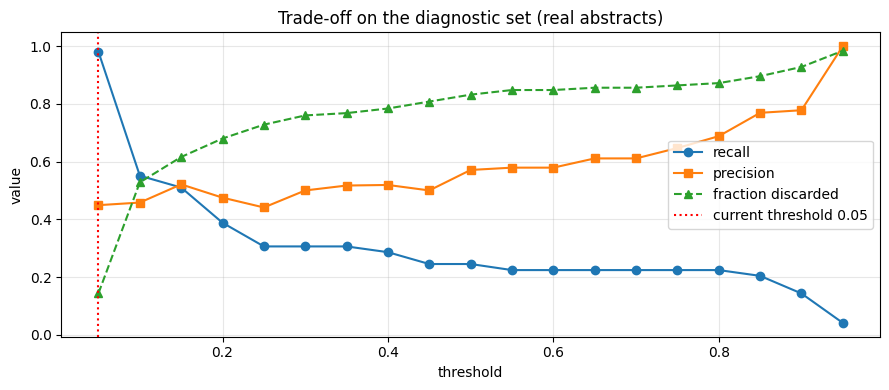

In [16]:
# ============================================================
# 14b. THRESHOLD TRADE-OFF: recall vs. screening workload
#      This is the table that decides TARGET_RECALL - and that goes in the protocol.
# ============================================================
diag_mask = (test_df["source"] == "diagnostic").values
if diag_mask.sum() == 0:
    print("[warning] no 'diagnostic' examples in test - using the whole test set.")
    diag_mask = np.ones(len(test_df), dtype=bool)

d_p = test_probs[diag_mask, POS_ID]
d_y = (test_labels[diag_mask] == POS_ID).astype(int)
print(f"Diagnostic set: {len(d_y)} real abstracts ({d_y.mean()*100:.1f}% positive)\n")

rows = []
for tr in np.linspace(0.05, 0.95, 19):
    p = (d_p >= tr).astype(int)
    rows.append({
        "threshold": round(tr, 2),
        "recall": round(recall_score(d_y, p, zero_division=0), 3),
        "precision": round(precision_score(d_y, p, zero_division=0), 3),
        "F1": round(f1_score(d_y, p, zero_division=0), 3),
        "pct_to_read": round(100 * p.mean(), 1),
        "pct_discarded": round(100 * (1 - p.mean()), 1),
        "eligible_missed": int(((d_y == 1) & (p == 0)).sum()),
    })
sweep_diag = pd.DataFrame(rows)
print(sweep_diag.to_string(index=False))

print("\n--- HOW TO READ ---")
print("'pct_discarded' is the real saving in screening workload.")
print("'eligible_missed' is the cost. Choose the threshold by looking at both columns.")

thr_now = float(chosen["thr"])
p_now = (d_p >= thr_now).astype(int)
print(f"\nCurrent threshold = {thr_now:.2f} (TARGET_RECALL={TARGET_RECALL})")
print(f"  recall {recall_score(d_y, p_now, zero_division=0):.3f} | "
      f"precision {precision_score(d_y, p_now, zero_division=0):.3f} | "
      f"discards {100*(1-p_now.mean()):.1f}% of the corpus | "
      f"misses {int(((d_y==1)&(p_now==0)).sum())} eligible")

print("\n=== Confusion matrix on the DIAGNOSTIC set (operating threshold) ===")
cmd = confusion_matrix(d_y, p_now)
print(pd.DataFrame(cmd,
      index=["true: Not related", "true: Sensing"],
      columns=["pred: Not related", "pred: Sensing"]).to_string())

plt.figure(figsize=(9, 4))
plt.plot(sweep_diag["threshold"], sweep_diag["recall"], marker="o", label="recall")
plt.plot(sweep_diag["threshold"], sweep_diag["precision"], marker="s", label="precision")
plt.plot(sweep_diag["threshold"], sweep_diag["pct_discarded"] / 100,
         marker="^", ls="--", label="fraction discarded")
plt.axvline(thr_now, color="red", ls=":", label=f"current threshold {thr_now:.2f}")
plt.xlabel("threshold"); plt.ylabel("value")
plt.title("Trade-off on the diagnostic set (real abstracts)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 15. Grouped cross-validation - the estimator you should report

With ~180 examples, a single 15% test split carries enormous uncertainty. `StratifiedGroupKFold`
respects the near-duplicate groups **and** uses the whole dataset for evaluation across folds. Run
this for the final numbers in the paper (it is expensive: 5 training runs).

In [17]:
# ============================================================
# 15. StratifiedGroupKFold (optional - enable when reporting)
# ============================================================
RUN_CV = False   # <- set to True when generating the final numbers
N_FOLDS = 5

if RUN_CV:
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_metrics = []
    for fold, (tr_i, te_i) in enumerate(sgkf.split(df, df["label_id"], groups=df["group_id"])):
        print(f"\n===== Fold {fold+1}/{N_FOLDS} =====")
        tr_fold = df.iloc[tr_i].reset_index(drop=True)
        te_fold = df.iloc[te_i].reset_index(drop=True)
        # inner sub-split for validation (also group-wise)
        inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        i_tr, i_va = next(inner.split(tr_fold, tr_fold["label_id"], groups=tr_fold["group_id"]))
        tr2, va2 = tr_fold.iloc[i_tr], tr_fold.iloc[i_va]

        m = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABEL_MAP),
            id2label=ID_TO_LABEL, label2id=LABEL_MAP,
            hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1)
        import copy
        args_f = copy.deepcopy(training_args)   # to_dict() breaks across versions
        args_f.output_dir = f"{OUTPUT_DIR}/fold{fold}"
        c = tr2["label_id"].value_counts().sort_index().values.astype(float)
        t = FocalLossTrainer(
            model=m, args=args_f,
            train_dataset=TextClsDataset(tr2["text"], tr2["label_id"], tokenizer),
            eval_dataset=TextClsDataset(va2["text"], va2["label_id"], tokenizer),
            data_collator=data_collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
            gamma=2.0, alpha=torch.tensor(c.sum() / (len(c) * c), dtype=torch.float))
        t.train()
        r = t.evaluate(TextClsDataset(te_fold["text"], te_fold["label_id"], tokenizer))
        print({k: round(v, 3) for k, v in r.items() if k.startswith("eval_")})
        fold_metrics.append(r)

    cv = pd.DataFrame(fold_metrics)
    print("\n===== Cross-validation summary =====")
    for c_ in ["eval_f1_macro", "eval_recall_pos", "eval_precision_pos", "eval_mcc"]:
        if c_ in cv:
            print(f"{c_:22s}: {cv[c_].mean():.3f} +/- {cv[c_].std():.3f}")
else:
    print("RUN_CV=False - skipping cross-validation.")

RUN_CV=False - skipping cross-validation.


In [18]:
# ============================================================
# 16. Error analysis
# ============================================================
results_df = test_df[["text", "label", "label_id", "source"]].copy().reset_index(drop=True)
results_df["pred_id"]    = test_thr_preds   # CORRECTED: uses the operating threshold, not argmax
results_df["pred_label"] = results_df["pred_id"].map(ID_TO_LABEL)
results_df["correct"]    = results_df["label_id"] == results_df["pred_id"]
results_df["confidence"] = test_probs.max(axis=1)     # CORRECTED: calibrated probabilities
results_df["p_pos"]      = test_probs[:, POS_ID]

mis = results_df[~results_df["correct"]]
print(f"Errors: {len(mis)} of {len(results_df)}")
for _, r in mis.head(8).iterrows():
    print(f"\n[{r['source']}] true={r['label']} | predicted={r['pred_label']} "
          f"(conf {r['confidence']:.3f})")
    print("  ", r["text"][:200], "...")

# performance by example origin: the column that matters is 'real'/'diagnostic'
print("\nAccuracy by example origin:")
print(results_df.groupby("source")["correct"].agg(["mean", "count"]).round(3))

# lowest-confidence cases = candidates for manual review
print("\nLowest confidence (review manually):")
for _, r in results_df.nsmallest(5, "confidence").iterrows():
    print(f"  {r['confidence']:.3f} | true={r['label']} | predicted={r['pred_label']}")

Errors: 81 of 316

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.938)
   From prediction to explanation: A machine learning and causal mediation framework for roadway crash risk with connected vehicle data. Traditional safety analysis often relies on static roadway attribu ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.937)
   Walkability under Climate Pressure: Application to Three UNESCO World Heritage Cities in Central Spain. Walkability is a modern concept that has become important in recent years due to the doubtless e ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.910)
   Measuring Streetscape Features with High-Density Aerial Light Detection and Ranging. This study investigates the feasibility of extracting streetscape features from high-density United States Geologic ...

[real] true=Not related | predicted=Sensing of walkability dimension (conf 0.697)
   From synthetic navigati

In [19]:
# ============================================================
# 17. Inference + deployment artefacts (consistent max_length)
# ============================================================
def predict(texts, model=None, tok=None, temp=None, threshold=None):
    model = model or trainer.model
    tok = tok or tokenizer
    temp = temperature if temp is None else temp
    threshold = float(chosen["thr"]) if threshold is None else threshold
    single = isinstance(texts, str)
    texts = [texts] if single else list(texts)

    model.eval().to(device)
    enc = tok(texts, truncation=True, padding=True,
              max_length=MAX_LEN, return_tensors="pt").to(device)   # SAME MAX_LEN as training
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits / temp, dim=-1).cpu().numpy()

    out = [{"predicted_label": ID_TO_LABEL[POS_ID] if p[POS_ID] >= threshold
                               else ID_TO_LABEL[1 - POS_ID],
            "p_positive": float(p[POS_ID]),
            "probabilities": {ID_TO_LABEL[i]: float(v) for i, v in enumerate(p)}}
           for p in probs]
    return out[0] if single else out

json.dump({
    "model_name": MODEL_NAME,
    "num_labels": len(LABEL_MAP),
    "id2label": {str(k): v for k, v in ID_TO_LABEL.items()},
    "label2id": LABEL_MAP,
    "max_length": MAX_LEN,
    "temperature": float(temperature),
    "decision_threshold": float(chosen["thr"]),
    "positive_class_id": POS_ID,
}, open(f"{OUTPUT_DIR}/model_config.json", "w"), indent=2)
print(f"Config saved to {OUTPUT_DIR}/model_config.json")

# splits persisted for auditing / reproducibility in the paper
for name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    d.drop(columns=["norm_text"], errors="ignore").to_json(
        f"{DATA_DIR}/{name}.json", orient="records", indent=2, force_ascii=False)
print(f"Splits saved to {DATA_DIR}/")

for r in predict([
    "This study deploys LiDAR and street-level imagery to quantify sidewalk width, "
    "shade coverage and surface quality along pedestrian corridors.",
    "We evaluate gait parameters in post-stroke patients using an instrumented walkway "
    "in a clinical laboratory setting.",
]):
    print(f"\n{r['predicted_label']}  (p_pos = {r['p_positive']:.3f})")

Config saved to ../model/output/model_config.json
Splits saved to ../model/dataset/

Sensing of walkability dimension  (p_pos = 0.349)

Sensing of walkability dimension  (p_pos = 0.054)


---

## What to do with the result of cell 7

If the audit verdict is **"trivially separable task"** (the most likely scenario, given
`val_loss = 1e-6`), fixing the split alone does not solve the underlying problem: the dataset is
too easy. The corrections that matter:

1. **Hard negatives.** Negatives must be articles a human would have to think about before
   rejecting: urban sensing that does not measure a walkability dimension (vehicle traffic sensors,
   air quality monitoring with no pedestrian link, purely aerial or satellite acquisition), street
   imagery used as survey stimulus rather than measurement data, and street audits targeting
   non-walkability constructs (crime risk, property values). These are exactly the three
   adjudication rules already formalised - they should generate the negatives, not merely filter
   the positives.

2. **More real annotation.** 67 real abstracts is thin for estimating performance. Sample ~300 from
   the ~1,600 corpus and label them manually. Use synthetics only for pre-training/augmentation,
   never for evaluation.

3. **Report the baseline.** A reviewer will ask. If TF-IDF + LogReg comes close to DeBERTa on the
   real subset, that is a finding to report, not to hide.

4. **Report human agreement.** Label a subset twice (or with a second annotator) and compute
   Cohen's kappa. The classifier's ceiling is annotation consistency - and systematic review
   reviewers expect that number.